# Bonds Pricing
## 1. Bond Price & Yield to Maturity (YTM)

In [2]:
# On importe ce dont on a besoin

import numpy as np 
import matplotlib.pyplot as plt



In [3]:
# On fixe les paramètres

face_value = 1000  # nominal
coupon_rate = 0.05 
maturity = 10 # maturité en années 
ytm = 0.05 # yield to maturity 


coupon = face_value * coupon_rate # pour avoir le coupon annuel 

print(f"Face Value     : {face_value}€")
print(f"Coupon Rate    : {coupon_rate*100}%")
print(f"Annual Coupon  : {coupon}€")
print(f"Maturity       : {maturity} years")
print(f"YTM            : {ytm*100}%")


Face Value     : 1000€
Coupon Rate    : 5.0%
Annual Coupon  : 50.0€
Maturity       : 10 years
YTM            : 5.0%


In [4]:
# On calcule le prix de l'obligation 

def bond_price(face_value, coupon, maturity, ytm):
    cash_flows = [coupon / (1+ytm)**t for t in range(1, maturity+1)]

    principal = face_value / (1+ytm)** maturity

    price = sum(cash_flows) + principal 

    return round(price,2)

price = bond_price(face_value, coupon, maturity, ytm)
print(f"Bond Price : {price}€")

Bond Price : 1000.0€


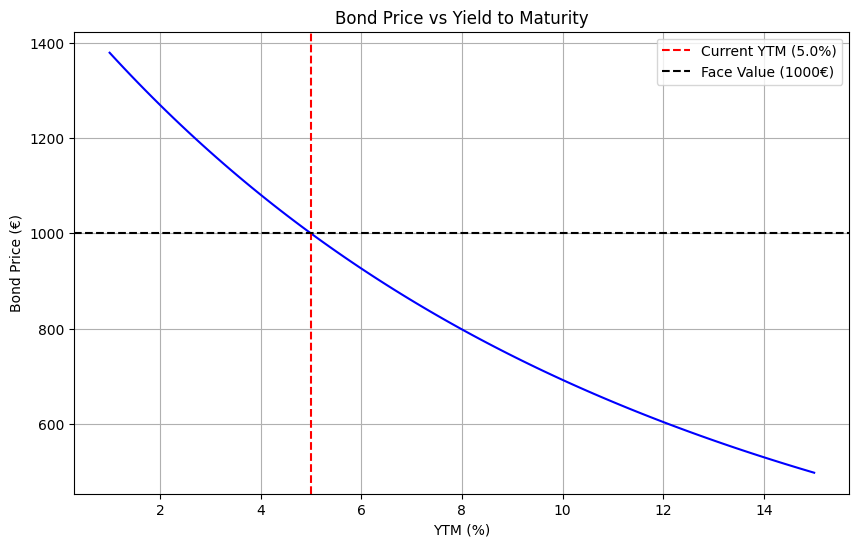

In [6]:
# On va regarder le prix vs YTM 

ytm_range = np.linspace(0.01, 0.15, 100)

prices = [bond_price(face_value, coupon, maturity, y) for y in ytm_range]


# le graph : 
plt.figure(figsize=(10, 6))
plt.plot(ytm_range * 100, prices, color="blue")
plt.axvline(x=ytm*100, color="red", linestyle="--", label=f"Current YTM ({ytm*100}%)")
plt.axhline(y=face_value, color="black", linestyle="--", label=f"Face Value ({face_value}€)")
plt.title("Bond Price vs Yield to Maturity")
plt.xlabel("YTM (%)")
plt.ylabel("Bond Price (€)")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# On s'occupe de la DURATION 

def duration(face_value, coupon, maturity, ytm) :

    price = bond_price(face_value, coupon, maturity, ytm)

    # weighted cash flows 
    weighted_cf = [t * (coupon / (1+ytm)**t) for t in range(1,1+maturity)]
    weighted_cf[-1] += maturity * (face_value / (1+ytm)**maturity)

    duration = sum(weighted_cf) / price 

    # modified duration 
    modified_duration = duration / (1+ytm)

    return round(duration, 4), round(modified_duration, 4)

mac_dur, mod_dur = duration(face_value, coupon, maturity, ytm)

print("=" * 40)
print("         DURATION SUMMARY")
print("=" * 40)
print(f"Macaulay Duration  : {mac_dur} years")
print(f"Modified Duration  : {mod_dur}")
print("=" * 40)

         DURATION SUMMARY
Macaulay Duration  : 8.1078 years
Modified Duration  : 7.7217


In [8]:
# On s'occupe de la convexité 

def convexity(face_value, coupon, maturity, ytm) : 
    price = bond_price(face_value, coupon, maturity, ytm)


# Weighted cash flows
    weighted_cf = [t * (t + 1) * (coupon / (1 + ytm)**(t + 2)) for t in range(1, maturity + 1)]
    weighted_cf[-1] += maturity * (maturity + 1) * (face_value / (1 + ytm)**(maturity + 2))
    
    convexity = sum(weighted_cf) / price
    
    return round(convexity, 4)

conv = convexity(face_value, coupon, maturity, ytm)

print("=" * 40)
print("        CONVEXITY SUMMARY")
print("=" * 40)
print(f"Convexity : {conv}")
print("=" * 40)

        CONVEXITY SUMMARY
Convexity : 74.9977


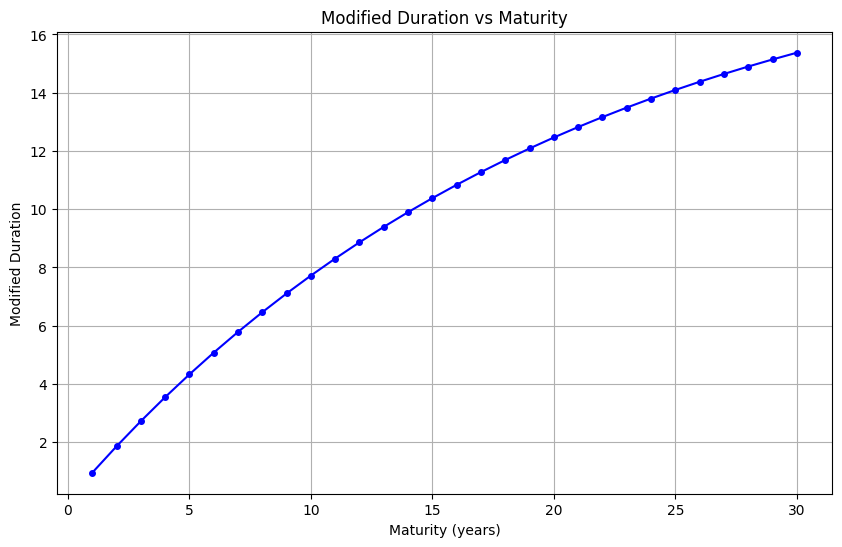

In [9]:
# Graph duration vs maturité : 

maturities = range(1, 31)

# On calcule la modified duration selon chaque maturité 
mod_durations = [duration(face_value, coupon, m, ytm)[1] for m in maturities]

# Graph
plt.figure(figsize=(10, 6))
plt.plot(maturities, mod_durations, color="blue", marker="o", markersize=4)
plt.title("Modified Duration vs Maturity")
plt.xlabel("Maturity (years)")
plt.ylabel("Modified Duration")
plt.grid(True)
plt.show()

In [10]:
# Résumé final de ce qu'on obtient :  

print("=" * 45)
print("         BOND PRICING SUMMARY")
print("=" * 45)
print(f"Face Value         : {face_value}€")
print(f"Coupon Rate        : {coupon_rate*100}%")
print(f"Annual Coupon      : {coupon}€")
print(f"Maturity           : {maturity} years")
print("-" * 45)
print(f"Bond Price         : {price}€")
print(f"YTM                : {ytm*100}%")
print("-" * 45)
print(f"Macaulay Duration  : {mac_dur} years")
print(f"Modified Duration  : {mod_dur}")
print(f"Convexity          : {conv}")
print("=" * 45)

         BOND PRICING SUMMARY
Face Value         : 1000€
Coupon Rate        : 5.0%
Annual Coupon      : 50.0€
Maturity           : 10 years
---------------------------------------------
Bond Price         : 1000.0€
YTM                : 5.0%
---------------------------------------------
Macaulay Duration  : 8.1078 years
Modified Duration  : 7.7217
Convexity          : 74.9977
